# Meeting 2026-07-01 — vanilla + cdrmix evotuning sweep (35M)

A new model variant for the DPO low-data learning curve: the **same** single-mask
`cdr_mix` C05 evotuning recipe as `evo_c05_cdrmix_35m`, but seeded from the
**untouched ESM2-35M** (`model.init.source=huggingface`) instead of the general
OAS-evotuned checkpoint. This isolates the effect of the C05 cdrmix fine-tune
from the prior general-OAS evotuning step.

**Selection = validation perplexity only** (`best.pt`, tracked by `best_val_ppl`).
No DMS/Spearman is used to pick the winner. Split is **95/5/0** (no test), with
val-ppl early stopping (`patience=2`).

**Screening sweep**: full factorial, single split salt `oas-v1`, **81 runs** —
`lr ∈ {2e-5,5e-5,8e-5}` × `cdr_mask_prob ∈ {0.5,0.6,0.7}` ×
`cdr_flank ∈ {1,3,5}` × `framework_mask_prob ∈ {0.0,0.05,0.1}`. Scoring disabled.

**Confirmation**: top 5 combos rerun on extra salts `oas-v2,oas-v3`
with `scoring=c05` (Spearman logged as a diagnostic only — selection still by ppl).


## DPO low-data learning curve — 35M models comparison

How does Spearman on the held-out test set change with training data size N,
comparing all 35M base models including the new **Vanilla+cdrmix 35M**
against: vanilla ESM2-35M, Evo-35M, Evo+C05 B25, Evo+C05 cdrmix?

**Zero-shot baselines** (dotted horizontal lines per model): Spearman on the test
set *without* any DPO fine-tuning (`num_epochs=0`, exact test-set evaluation).

**Dense grid** around 1%: additional points at 2%, 4%, 8%
(N = 4406, 8811, 17623) fill in the convergence zone between 1% and 10%.


In [18]:
# === DPO learning curve setup (shared helpers, reads from $TRAIN_DIR) =========
%matplotlib inline
import os, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory
import yaml

_REPO_ROOT = _find_repo_root(Path.cwd()) if "REPO_ROOT" in dir() else None
if _REPO_ROOT is None:
    for _d in [Path.cwd(), *Path.cwd().parents]:
        if (_d / "conf" / "analysis" / "models.yaml").exists():
            _REPO_ROOT = _d; break

def _dpo_train_dir() -> Path:
    user = os.environ.get("USER", "unknown")
    scratch = os.environ.get("SCRATCH_DIR", f"/cluster/scratch/{user}/protein-design")
    return Path(os.environ.get("TRAIN_DIR", str(Path(scratch) / "train")))

_TRAIN_DIR   = _dpo_train_dir()
_METRIC      = "test_spearman_avg"
_BASE_RE     = re.compile(r"^lowdata_(?P<model>.+)_n(?P<n>\d+)_s(?P<seed>\d+)$")
_ZEROSHOT_RE = re.compile(r"^zeroshot_(?P<model>.+)_(?P<ts>ed\d)_s(?P<seed>\d+)$")
_TS_RE       = re.compile(r"_\d{8}_\d{6}$")

_REG_LC = yaml.safe_load((_REPO_ROOT / "conf" / "analysis" / "models.yaml").read_text()).get("models", {})
def _lc_label(key): return _REG_LC.get(key, {}).get("label") or key
def _lc_color(key, i=0):
    c = _REG_LC.get(key, {}).get("color")
    cyc = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    return c if c else cyc[i % len(cyc)]

def _ts_of(run_dir: Path) -> str:
    cfg = run_dir / "resolved_config.yaml"
    key = "ed5_m22"
    if cfg.exists():
        try:
            c = yaml.safe_load(cfg.read_text())
            key = (((c or {}).get("data", {}) or {}).get("test", {}) or {}).get("dataset_key", key)
        except Exception: pass
    return str(key).replace("_m22", "")

def _scan_runs_lc(train_dir=_TRAIN_DIR, metric=_METRIC) -> pd.DataFrame:
    best = {}
    for p in sorted(train_dir.glob("lowdata_*_n*_s*")):
        summ = p / "summary.json"
        if not summ.exists(): continue
        m = _BASE_RE.match(_TS_RE.sub("", p.name))
        if not m: continue
        ts = _ts_of(p)
        key = (m.group("model"), int(m.group("n")), int(m.group("seed")), ts)
        mt = summ.stat().st_mtime
        if key in best and best[key][0] >= mt: continue
        try: val = json.loads(summ.read_text()).get(metric)
        except Exception: val = None
        best[key] = (mt, str(p), val)
    rows = [{"model": k[0], "n_train": k[1], "seed": k[2], "test_set": k[3],
             metric: v[2], "run_dir": v[1]} for k, v in best.items()]
    cols = ["model", "n_train", "seed", "test_set", metric, "run_dir"]
    if not rows: return pd.DataFrame(columns=cols)
    return pd.DataFrame(rows).sort_values(["test_set", "model", "n_train", "seed"]).reset_index(drop=True)

def _scan_zeroshot_lc(train_dir=_TRAIN_DIR, metric=_METRIC) -> pd.DataFrame:
    rows = []
    for p in sorted(train_dir.glob("zeroshot_*_s*")):
        summ = p / "summary.json"
        if not summ.exists(): continue
        m = _ZEROSHOT_RE.match(_TS_RE.sub("", p.name))  # strip timestamp before matching
        if not m: continue
        try: val = json.loads(summ.read_text()).get(metric)
        except Exception: val = None
        rows.append({"model": m.group("model"), "test_set": m.group("ts"),
                     "seed": int(m.group("seed")), metric: val})
    cols = ["model", "test_set", "seed", metric]
    if not rows: return pd.DataFrame(columns=cols)
    return pd.DataFrame(rows).sort_values(["model", "test_set"]).reset_index(drop=True)

_LINESTYLE = {"ed2": "-", "ed5": "--"}

def _plot_lc(models, test_sets, df, metric=_METRIC, min_seeds=1,
             zero_shot_df=None, title="", save_path=None):
    fin = df[pd.to_numeric(df[metric], errors="coerce").notna()].copy()
    fin[metric] = pd.to_numeric(fin[metric])
    avail_ts = [t for t in test_sets if t in set(fin["test_set"])]
    fig, ax = plt.subplots(figsize=(8, 5))
    used_models, used_ts = [], []
    for i, mk in enumerate(models):
        color = _lc_color(mk, i)
        for ts in avail_ts:
            sub = fin[(fin["model"] == mk) & (fin["test_set"] == ts)]
            if sub.empty: continue
            agg = (sub.groupby("n_train")[metric]
                      .agg(mean="mean", std="std", n="size").reset_index()
                      .sort_values("n_train"))
            agg = agg[agg["n"] >= min_seeds]
            if agg.empty: continue
            ax.plot(agg["n_train"], agg["mean"], marker="o", color=color,
                    ls=_LINESTYLE.get(ts, "-"))
            std = agg["std"].fillna(0.0)
            ax.fill_between(agg["n_train"], agg["mean"] - std, agg["mean"] + std,
                            color=color, alpha=0.12)
            if mk not in used_models: used_models.append(mk)
            if ts not in used_ts: used_ts.append(ts)
    has_zs = False
    if zero_shot_df is not None and not zero_shot_df.empty:
        zs = zero_shot_df[pd.to_numeric(zero_shot_df[metric], errors="coerce").notna()].copy()
        zs[metric] = pd.to_numeric(zs[metric])
        # blended transform: x in axes fraction, y in data coordinates
        trans = blended_transform_factory(ax.transAxes, ax.transData)
        for i, mk in enumerate(used_models):
            color = _lc_color(mk, models.index(mk))
            for ts in avail_ts:
                sub = zs[(zs["model"] == mk) & (zs["test_set"] == ts)]
                if sub.empty: continue
                val = float(sub[metric].mean())
                # short tick protruding left from the y-axis
                ax.plot([-0.04, 0.0], [val, val], color=color, lw=2.5,
                        transform=trans, clip_on=False)
                has_zs = True
    if not used_models:
        print("Nothing to plot."); plt.close(fig); return None
    ax.set_xscale("log")
    ax.set_xlabel("# training sequences (N)")
    ax.set_ylabel("Spearman (held-out test)")
    ax.set_title(title or "DPO low-data learning curve")
    ax.axhline(0.0, color="0.7", lw=0.8, ls=":", zorder=0)
    ax.grid(True, which="both", alpha=0.2)
    mh = [Line2D([0],[0], color=_lc_color(m, models.index(m)), lw=2, label=_lc_label(m))
          for m in used_models]
    th = [Line2D([0],[0], color="0.3", lw=2, ls=_LINESTYLE.get(t, "-"), label=f"{t} test")
          for t in used_ts]
    if has_zs:
        th.append(Line2D([0],[0], color="0.3", lw=2.5, label="← zero-shot (y-axis ticks)"))
    leg1 = ax.legend(handles=mh, frameon=False, fontsize=9, loc="upper left")
    ax.add_artist(leg1)
    ax.legend(handles=th, frameon=False, fontsize=9, loc="lower right")
    fig.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight"); print("Saved:", save_path)
    return fig

_lc_runs_df    = _scan_runs_lc()
_lc_zeroshot   = _scan_zeroshot_lc()
_LC_MODELS     = sorted(_lc_runs_df["model"].unique()) if not _lc_runs_df.empty else []
_ED2_TOTAL     = 220283
_ED5_N         = [50, 200, 2000, 4406, 8811, 17623, 22028, 220283]
print(f"DPO runs found: {len(_lc_runs_df)}")
print(f"Zero-shot evals found: {len(_lc_zeroshot)}")
print(f"Models available: {_LC_MODELS}")

DPO runs found: 291
Zero-shot evals found: 10
Models available: ['evo_35m', 'evo_c05_blosum25', 'evo_c05_cdrmix_35m', 'vanilla_35m', 'vanilla_cdrmix_35m']


Saved: /cluster/home/mdenegri/protein-design/report/figures/dpo_lowdata_curve_ed2_0701.pdf


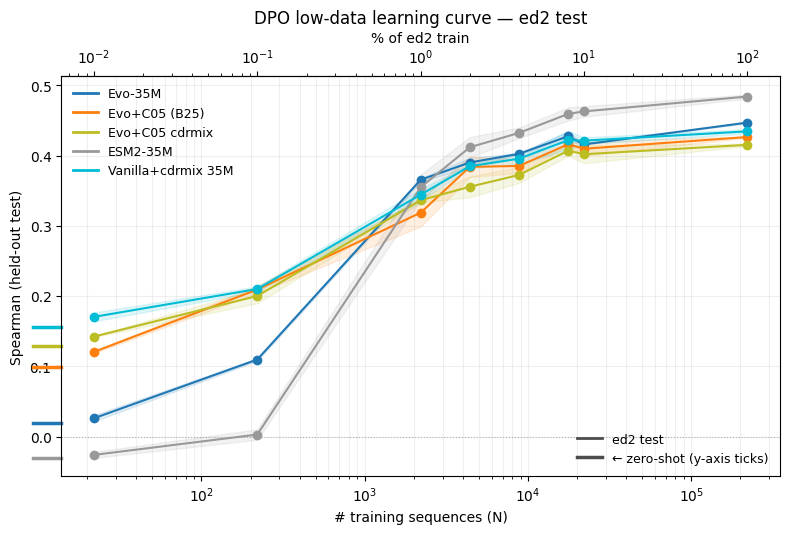

In [19]:
# === DPO learning curve — ed2 test ====================================
fig_lc_ed2 = _plot_lc(
    _LC_MODELS, ["ed2"], _lc_runs_df,
    zero_shot_df=_lc_zeroshot,
    title="DPO low-data learning curve — ed2 test",
    save_path=str(_REPO_ROOT / "report" / "figures" / "dpo_lowdata_curve_ed2_0701.pdf"),
)
if fig_lc_ed2 is not None:
    secax = fig_lc_ed2.axes[0].secondary_xaxis(
        "top",
        functions=(lambda x: 100 * x / _ED2_TOTAL, lambda p: p * _ED2_TOTAL / 100),
    )
    secax.set_xlabel("% of ed2 train")
    plt.show()


Saved: /cluster/home/mdenegri/protein-design/report/figures/dpo_lowdata_curve_ed5_0701.pdf


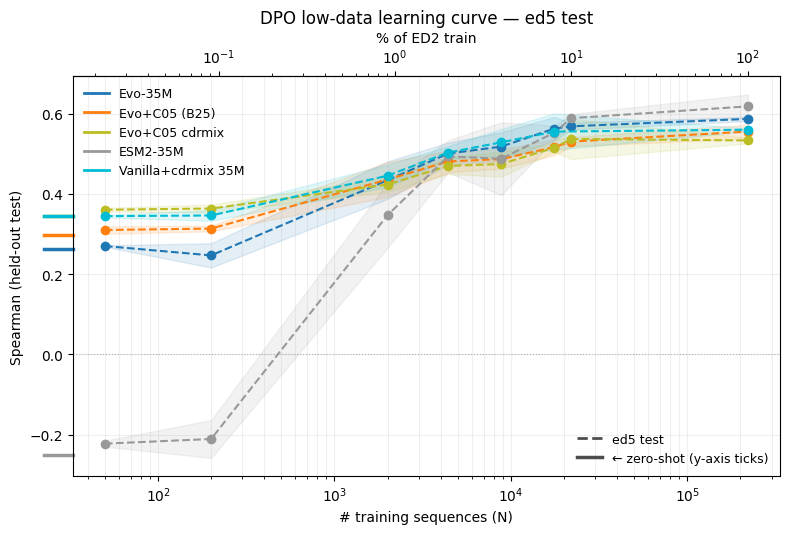

In [20]:
# === DPO learning curve — ed5 test ====================================
_df_ed5_lc = _lc_runs_df[_lc_runs_df["n_train"].isin(_ED5_N)]
fig_lc_ed5 = _plot_lc(
    _LC_MODELS, ["ed5"], _df_ed5_lc,
    zero_shot_df=_lc_zeroshot,
    title="DPO low-data learning curve — ed5 test",
    save_path=str(_REPO_ROOT / "report" / "figures" / "dpo_lowdata_curve_ed5_0701.pdf"),
)
if fig_lc_ed5 is not None:
    secax = fig_lc_ed5.axes[0].secondary_xaxis(
        "top",
        functions=(lambda x: 100 * x / _ED2_TOTAL, lambda p: p * _ED2_TOTAL / 100),
    )
    secax.set_xlabel("% of ED2 train")
    plt.show()


## Embedding-probe learning curve — 35M models (20 seeds)

A *separate* learning curve from the DPO one above: instead of DPO-fine-tuning,
this is the **frozen-backbone linear probe** (the `learning_curve.pdf` analysis
from the 2026-06-24 meeting), here recomputed for the **35M** family.

**How it works.** For each (model, DMS dataset) we cache the model's CDR-H3
embedding (ESM2 encoder, no gradients, last hidden state **mean-pooled over the
24 CDR-H3 token positions**; constant framework), then fit a **Ridge** (α=10,
features standardized) on a **random subset of the train split** to predict the
experimental binding **enrichment**, and score **Spearman ρ** on the *fixed*
test split. Repeating over train sizes (25…5000) gives a curve; a model whose
curve sits higher at small N organizes the binding signal more linearly = a
better small-data / DPO starting base.

**This run.** Models compared: `vanilla_35m` (untouched ESM2-35M), `evo_35m`
(general OAS evotuning), `vanilla_cdrmix_35m` (the C05 cdrmix winner from the
sweep above, seeded from vanilla). **`n_repeats=20`** random subsets per size
(vs. 5 in the 650M run) for tighter ±1 std bands → statistically solid.

Computed on a compute node (embeddings cached via `extract.sbatch --what emb`,
then `probe.sbatch --mode curve --models … --n-repeats 20 --out-name
learning_curve_35m`); the cell below only **reads back** `learning_curve_35m.csv`.


Saved: /cluster/home/mdenegri/protein-design/report/figures/learning_curve_35m.pdf


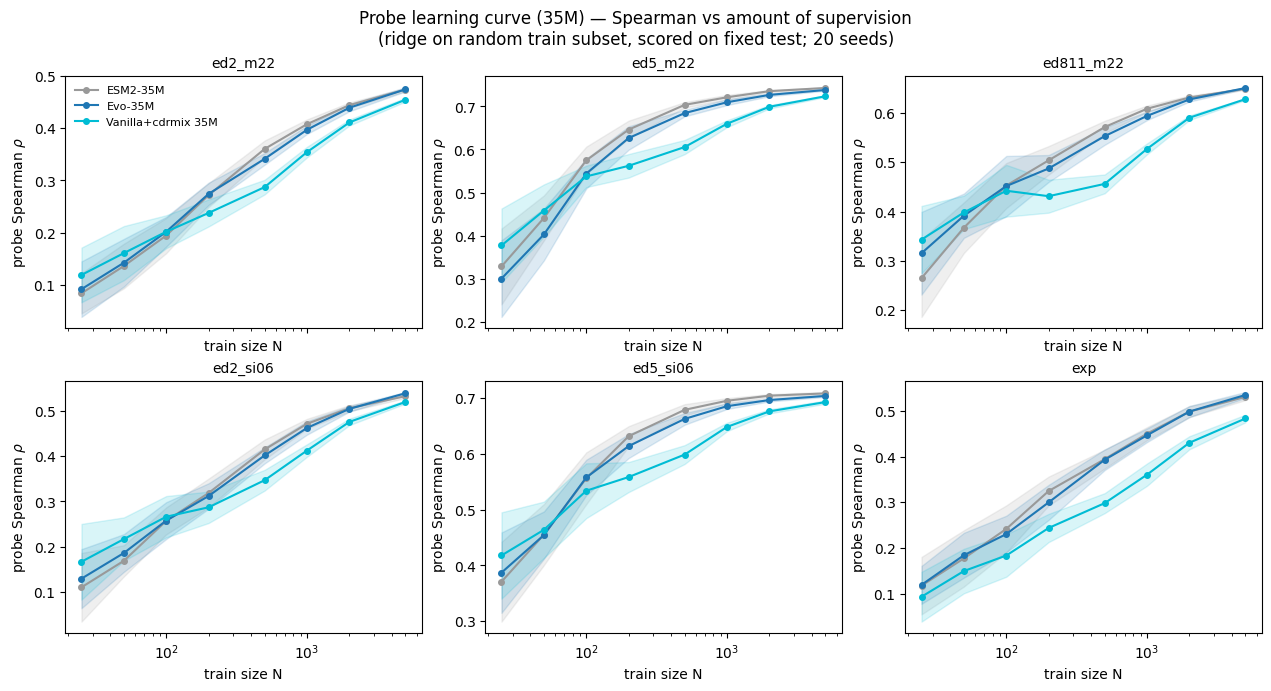

In [4]:
# === Embedding-probe learning curve (35M, 20 seeds): read cached CSV & plot ===
# Source CSV is produced on a compute node (does NOT recompute the probe here):
#   sbatch bash_scripts/probe.sbatch --mode curve \
#       --models vanilla_35m,evo_35m,vanilla_cdrmix_35m \
#       --n-repeats 20 --out-name learning_curve_35m
# One panel per DMS dataset, one line per model: mean ridge Spearman (fixed test
# split) vs train-set size N; shaded band = +/-1 std across the 20 reseeded repeats.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

def _find_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "conf" / "analysis" / "models.yaml").exists():
            return d
    raise FileNotFoundError("repo root not found (conf/analysis/models.yaml).")

_ROOT = _find_root(Path.cwd())
_REG = yaml.safe_load((_ROOT / "conf" / "analysis" / "models.yaml").read_text()).get("models", {})
def _mlabel(k): return _REG.get(k, {}).get("label") or k
def _mcolor(k, i):
    c = _REG.get(k, {}).get("color")
    cyc = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    return c if c else cyc[i % len(cyc)]

# Plot the models in this fixed order (matches the extraction/probe run).
PROBE_MODELS = ["vanilla_35m", "evo_35m", "vanilla_cdrmix_35m"]

lc_csv = _ROOT / "report" / "figures" / "learning_curve_35m.csv"
lc = pd.read_csv(lc_csv)

ds_keys = list(lc["dataset"].unique())
ncols = min(3, len(ds_keys))
nrows = -(-len(ds_keys) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows),
                         constrained_layout=True, squeeze=False, sharex=True)
for ax, ds in zip(axes.flat, ds_keys):
    for i, mk in enumerate(PROBE_MODELS):
        sub = lc[(lc["model"] == mk) & (lc["dataset"] == ds)].sort_values("n_train")
        if sub.empty:
            continue
        color = _mcolor(mk, i)
        ax.plot(sub["n_train"], sub["ridge_spearman_mean"], marker="o", ms=4,
                color=color, label=_mlabel(mk))
        ax.fill_between(sub["n_train"],
                        sub["ridge_spearman_mean"] - sub["ridge_spearman_std"],
                        sub["ridge_spearman_mean"] + sub["ridge_spearman_std"],
                        color=color, alpha=0.15)
    ax.set_xscale("log")
    ax.set_title(ds, fontsize=10)
    ax.set_xlabel("train size N")
    ax.set_ylabel(r"probe Spearman $\rho$")
for ax in axes.flat[len(ds_keys):]:
    ax.set_visible(False)
axes.flat[0].legend(fontsize=8, frameon=False)
n_rep = int(lc["n_repeats"].max())
fig.suptitle(f"Probe learning curve (35M) — Spearman vs amount of supervision\n"
             f"(ridge on random train subset, scored on fixed test; {n_rep} seeds)")
out = _ROOT / "report" / "figures" / "learning_curve_35m.pdf"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, bbox_inches="tight"); print("Saved:", out)
plt.show()


In [5]:
# === setup + scan the vanilla cdrmix sweep ==========================
%matplotlib inline
import os, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

def _find_repo_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "conf" / "analysis" / "models.yaml").exists():
            return d
    raise FileNotFoundError("repo root not found (conf/analysis/models.yaml).")

REPO_ROOT = _find_repo_root(Path.cwd())

def _train_dir() -> Path:
    user = os.environ.get("USER", "unknown")
    scratch = os.environ.get("SCRATCH_DIR", f"/cluster/scratch/{user}/protein-design")
    return Path(os.environ.get("TRAIN_DIR", str(Path(scratch) / "train")))

TRAIN_DIR = _train_dir()
TS_RE = re.compile(r"_\d{8}_\d{6}$")  # run dir = <run_name>_<YYYYMMDD_HHMMSS>

# ---- the intended 81-combo screening grid (string literals match the sweep
#      script EXACTLY so run_name reconstruction is byte-identical) -----------
NAME_PREFIX = "vanilla_cdrmix_35m"
LR_GRID    = ["2.0e-5", "5.0e-5", "8.0e-5"]
CMP_GRID   = ["0.5", "0.6", "0.7"]
FLANK_GRID = ["1", "3", "5"]
FMP_GRID   = ["0.0", "0.05", "0.1"]
SCREEN_SALT = "oas-v1"

def run_name_of(lr, cmp, flank, fmp, salt):
    return f"{NAME_PREFIX}_lr{lr}_cmp{cmp}_flank{flank}_fmp{fmp}_{salt}"

def _latest_run_dir(run_name: str, train_dir: Path = TRAIN_DIR):
    """Most-recent <run_name>_<ts>/ that has a summary.json (i.e. finished).
    Returns None if no finished run exists yet."""
    pat = re.compile(r"^" + re.escape(run_name) + r"_\d{8}_\d{6}$")
    best = None  # (mtime, path)
    for p in train_dir.glob(run_name + "_*"):
        if not pat.match(p.name):
            continue
        summ = p / "summary.json"
        if not summ.exists():
            continue
        mt = summ.stat().st_mtime
        if best is None or mt > best[0]:
            best = (mt, p)
    return None if best is None else best[1]

def _best_val_ppl(run_dir: Path):
    """Min val perplexity over per-epoch evals (best.pt selection criterion).
    Reads history.csv (authoritative); falls back to summary.json's final ppl."""
    h = run_dir / "history.csv"
    if h.exists():
        df = pd.read_csv(h)
        if "val/perplexity" in df.columns:
            s = pd.to_numeric(df["val/perplexity"], errors="coerce").dropna()
            if len(s):
                return float(s.min())
    s = run_dir / "summary.json"
    if s.exists():
        try:
            return float(json.loads(s.read_text()).get("val_perplexity"))
        except Exception:
            pass
    return np.nan

def _best_spearman_val(run_dir: Path):
    """Max masked-position M22 val Spearman (only present when scoring=c05).
    Diagnostic only — never used for selection."""
    h = run_dir / "history.csv"
    if h.exists():
        df = pd.read_csv(h)
        if "eval/spearman_M22_val" in df.columns:
            s = pd.to_numeric(df["eval/spearman_M22_val"], errors="coerce").dropna()
            if len(s):
                return float(s.max())
    return np.nan

def scan_grid(lr_g, cmp_g, flank_g, fmp_g, salts):
    """Enumerate the full intended grid; for each combo, attach metrics from the
    most-recent FINISHED run (NaN/None when not yet finished — never an error)."""
    rows = []
    for lr in lr_g:
        for cmp in cmp_g:
            for flank in flank_g:
                for fmp in fmp_g:
                    for salt in salts:
                        rn = run_name_of(lr, cmp, flank, fmp, salt)
                        rd = _latest_run_dir(rn)
                        rows.append(dict(
                            lr=lr, cmp=cmp, flank=flank, fmp=fmp, salt=salt,
                            run_name=rn,
                            finished=rd is not None,
                            best_val_ppl=_best_val_ppl(rd) if rd is not None else np.nan,
                            spearman_val=_best_spearman_val(rd) if rd is not None else np.nan,
                            run_dir=str(rd) if rd is not None else "",
                        ))
    return pd.DataFrame(rows)

grid_df = scan_grid(LR_GRID, CMP_GRID, FLANK_GRID, FMP_GRID, [SCREEN_SALT])
n_total = len(grid_df)
n_done = int(grid_df["finished"].sum())
print(f"TRAIN_DIR = {TRAIN_DIR}")
print(f"Screening grid (salt={SCREEN_SALT}): {n_done}/{n_total} finished, "
      f"{n_total - n_done} missing.")

# cross-reference any sweep manifest(s) under bash_scripts/logs/ (informational)
manifests = sorted((REPO_ROOT / "bash_scripts" / "logs").glob("sweep_evotuning_cdrmix_*.csv"))
if manifests:
    print("\nSweep manifests found:")
    for m in manifests:
        try:
            mdf = pd.read_csv(m)
            print(f"  {m.name}: {len(mdf)} rows")
        except Exception as e:
            print(f"  {m.name}: unreadable ({e})")
else:
    print("\nNo sweep manifest CSVs found under bash_scripts/logs/ "
          "(scanning $TRAIN_DIR directly).")

display(grid_df[grid_df["finished"]].sort_values("best_val_ppl")
        [["lr", "cmp", "flank", "fmp", "best_val_ppl"]].head(10)
        .round(5).reset_index(drop=True))


TRAIN_DIR = /cluster/scratch/mdenegri/protein-design/train
Screening grid (salt=oas-v1): 81/81 finished, 0 missing.

Sweep manifests found:
  sweep_evotuning_cdrmix_20260624_143131.csv: 81 rows
  sweep_evotuning_cdrmix_20260625_112339.csv: 2 rows
  sweep_evotuning_cdrmix_20260625_112354.csv: 2 rows
  sweep_evotuning_cdrmix_20260625_112504.csv: 2 rows
  sweep_evotuning_cdrmix_20260625_112509.csv: 2 rows
  sweep_evotuning_cdrmix_20260625_112510.csv: 2 rows
  sweep_evotuning_cdrmix_resubmit_24g_20260625.csv: 73 rows


,lr,cmp,flank,fmp,best_val_ppl
0,8.0e-5,0.6,5,0.05,1.25646
1,8.0e-5,0.7,5,0.05,1.25865
2,8.0e-5,0.7,5,0.1,1.26002
3,8.0e-5,0.5,5,0.1,1.26121
4,8.0e-5,0.6,5,0.1,1.26154
5,8.0e-5,0.5,5,0.0,1.26754
6,8.0e-5,0.5,5,0.05,1.27003
7,5.0e-5,0.6,5,0.05,1.27144
8,5.0e-5,0.5,5,0.0,1.27258
9,5.0e-5,0.7,5,0.0,1.27356


## Missing experiments — copy-paste relaunch commands

Every screening combo that has **not** finished (no `summary.json` under
`$TRAIN_DIR`) is listed below with the exact command to (re)launch just that one
combo. Commands are printed, **not** executed by the notebook.


In [6]:
# === missing-combo relaunch commands ================================
missing = grid_df[~grid_df["finished"]]
print(f"{len(missing)} / {len(grid_df)} combos missing.\n")

if missing.empty:
    print("All 81 screening runs finished — nothing to relaunch.")
else:
    print("# --- via the sweep script (one combo each) ---")
    for _, r in missing.iterrows():
        print(
            f"bash_scripts/sweep_evotuning_cdrmix.sh "
            f"--model-preset esm2_35m --freeze-layers 0 --init-source huggingface "
            f"--name-prefix {NAME_PREFIX} "
            f"--lr-grid {r.lr} --cmp-grid {r.cmp} --flank-grid {r.flank} "
            f"--fmp-grid {r.fmp} --salt-grid {r.salt}"
        )
    print("\n# --- equivalently, raw sbatch lines ---")
    for _, r in missing.iterrows():
        print(
            f"sbatch bash_scripts/train.sbatch evotuning_cdrmix "
            f"model=esm2_35m model.init.source=huggingface "
            f"model.freeze_first_n_layers=0 scoring=none "
            f"training.learning_rate={r.lr} data.cdr_mask_prob={r.cmp} "
            f"data.cdr_flank={r.flank} data.framework_mask_prob={r.fmp} "
            f"data.split.salt={r.salt} run_name={r.run_name}"
        )


0 / 81 combos missing.

All 81 screening runs finished — nothing to relaunch.


## Sweep comparison — `best_val_ppl` across the 4 swept dimensions

One heatmap panel per `(cdr_flank, framework_mask_prob)` pair (rows = flank,
cols = fmp). Within each panel: `learning_rate` (y) × `cdr_mask_prob` (x), colored
by `best_val_ppl` (lower = better). Unfinished combos render blank. Uses only
finished runs; the global best combo is printed below.


Saved: /cluster/home/mdenegri/protein-design/report/figures/vanilla_cdrmix_35m_sweep_valppl.pdf


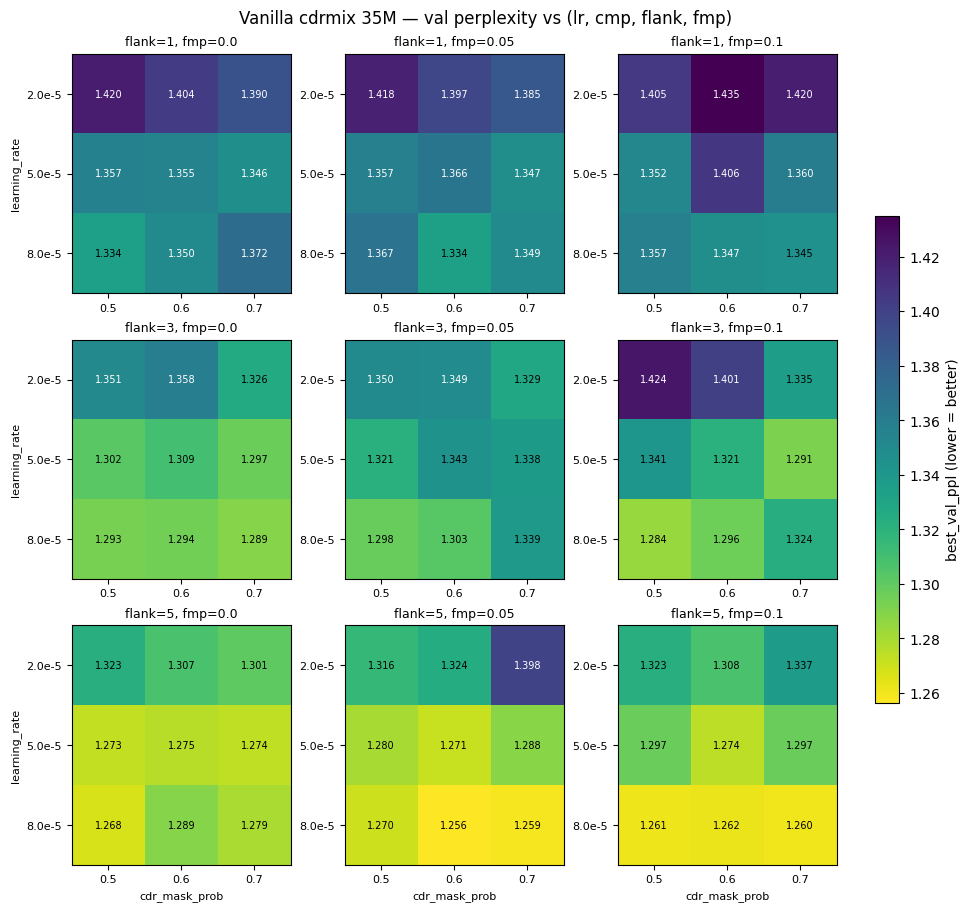


Current best combo by best_val_ppl (81/81 finished):
  lr=8.0e-5  cmp=0.6  flank=5  fmp=0.05  ->  best_val_ppl=1.25646
  run_dir = /cluster/scratch/mdenegri/protein-design/train/vanilla_cdrmix_35m_lr8.0e-5_cmp0.6_flank5_fmp0.05_oas-v1_20260625_090333


In [7]:
# === best_val_ppl heatmaps: lr x cmp, panel per (flank, fmp) ========
fin = grid_df[grid_df["finished"] & grid_df["best_val_ppl"].notna()].copy()

if fin.empty:
    print("No finished runs with a val ppl yet — nothing to plot.")
else:
    vmin, vmax = fin["best_val_ppl"].min(), fin["best_val_ppl"].max()
    nrow, ncol = len(FLANK_GRID), len(FMP_GRID)
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 3.0 * nrow),
                             squeeze=False, constrained_layout=True)
    lrs = list(LR_GRID)          # y axis (top -> bottom as given)
    cmps = list(CMP_GRID)        # x axis
    im = None
    for i, flank in enumerate(FLANK_GRID):
        for j, fmp in enumerate(FMP_GRID):
            ax = axes[i][j]
            M = np.full((len(lrs), len(cmps)), np.nan)
            sub = grid_df[(grid_df.flank == flank) & (grid_df.fmp == fmp)]
            for _, r in sub.iterrows():
                if r.finished and not np.isnan(r.best_val_ppl):
                    M[lrs.index(r.lr), cmps.index(r.cmp)] = r.best_val_ppl
            im = ax.imshow(M, cmap="viridis_r", vmin=vmin, vmax=vmax, aspect="auto")
            ax.set_xticks(range(len(cmps))); ax.set_xticklabels(cmps, fontsize=8)
            ax.set_yticks(range(len(lrs)));  ax.set_yticklabels(lrs, fontsize=8)
            ax.set_title(f"flank={flank}, fmp={fmp}", fontsize=9)
            if i == nrow - 1: ax.set_xlabel("cdr_mask_prob", fontsize=8)
            if j == 0:        ax.set_ylabel("learning_rate", fontsize=8)
            mid = (vmin + vmax) / 2
            for a in range(len(lrs)):
                for b in range(len(cmps)):
                    if np.isnan(M[a, b]):
                        continue
                    ax.text(b, a, f"{M[a, b]:.3f}", ha="center", va="center",
                            fontsize=7, color="white" if M[a, b] > mid else "black")
    if im is not None:
        fig.colorbar(im, ax=axes, shrink=0.6, label="best_val_ppl (lower = better)")
    fig.suptitle("Vanilla cdrmix 35M — val perplexity vs (lr, cmp, flank, fmp)")
    out = REPO_ROOT / "report" / "figures" / "vanilla_cdrmix_35m_sweep_valppl.pdf"
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, bbox_inches="tight"); print("Saved:", out)
    plt.show()

    best = fin.sort_values("best_val_ppl").iloc[0]
    print(f"\nCurrent best combo by best_val_ppl ({n_done}/{n_total} finished):")
    print(f"  lr={best.lr}  cmp={best.cmp}  flank={best.flank}  fmp={best.fmp}"
          f"  ->  best_val_ppl={best.best_val_ppl:.5f}")
    print(f"  run_dir = {best.run_dir}")


## Confirmation stage — relaunch top combos on extra salts

Take the top 5 hyperparameter combos by `best_val_ppl` and rerun each on
**additional** split salts (`oas-v2,oas-v3`) with `scoring=c05`, to check the
winner isn't an artifact of one split (and to log Spearman as a diagnostic).
`oas-v1` already exists from screening, so we only add `oas-v2,oas-v3`.

`TOP_COMBOS` defaults to the top 5 finished combos — **edit it** to pick exactly
the combos you want to confirm. Commands are printed, not executed.


In [8]:
# === confirmation-stage launch commands =============================
TOP_K = 5
_fin = grid_df[grid_df["finished"] & grid_df["best_val_ppl"].notna()]
# (lr, cmp, flank, fmp) tuples; edit this list directly to override.
TOP_COMBOS = [
    (r.lr, r.cmp, r.flank, r.fmp)
    for _, r in _fin.sort_values("best_val_ppl").head(TOP_K).iterrows()
]
print("TOP_COMBOS (edit above to change):")
for c in TOP_COMBOS:
    print("  ", c)
print()

if not TOP_COMBOS:
    print("No finished combos yet — run the screening sweep first.")
else:
    print("# confirmation runs (oas-v2 + oas-v3, scoring=c05) — one per combo:")
    for lr, cmp, flank, fmp in TOP_COMBOS:
        print(
            f"bash_scripts/sweep_evotuning_cdrmix.sh "
            f"--model-preset esm2_35m --freeze-layers 0 --init-source huggingface "
            f"--name-prefix {NAME_PREFIX} "
            f"--lr-grid {lr} --cmp-grid {cmp} --flank-grid {flank} --fmp-grid {fmp} "
            f"--salt-grid oas-v2,oas-v3 --scoring c05"
        )


TOP_COMBOS (edit above to change):
   ('8.0e-5', '0.6', '5', '0.05')
   ('8.0e-5', '0.7', '5', '0.05')
   ('8.0e-5', '0.7', '5', '0.1')
   ('8.0e-5', '0.5', '5', '0.1')
   ('8.0e-5', '0.6', '5', '0.1')

# confirmation runs (oas-v2 + oas-v3, scoring=c05) — one per combo:
bash_scripts/sweep_evotuning_cdrmix.sh --model-preset esm2_35m --freeze-layers 0 --init-source huggingface --name-prefix vanilla_cdrmix_35m --lr-grid 8.0e-5 --cmp-grid 0.6 --flank-grid 5 --fmp-grid 0.05 --salt-grid oas-v2,oas-v3 --scoring c05
bash_scripts/sweep_evotuning_cdrmix.sh --model-preset esm2_35m --freeze-layers 0 --init-source huggingface --name-prefix vanilla_cdrmix_35m --lr-grid 8.0e-5 --cmp-grid 0.7 --flank-grid 5 --fmp-grid 0.05 --salt-grid oas-v2,oas-v3 --scoring c05
bash_scripts/sweep_evotuning_cdrmix.sh --model-preset esm2_35m --freeze-layers 0 --init-source huggingface --name-prefix vanilla_cdrmix_35m --lr-grid 8.0e-5 --cmp-grid 0.7 --flank-grid 5 --fmp-grid 0.1 --salt-grid oas-v2,oas-v3 --scoring c05
b

## Final comparison — split uncertainty + ppl↔Spearman diagnostic

For each top candidate, aggregate `best_val_ppl` across all available salts
(`oas-v1` from screening + `oas-v2,oas-v3` from confirmation) → mean ± std.
**Winner = lowest mean val ppl** (selection rule; explicit). Alongside, the
logged M22-val Spearman (from the `scoring=c05` confirmation runs) is reported to
*visually check* how well val-ppl selection tracks the DMS metric — diagnostic
only, never used to pick. Partially-finished confirmation runs are flagged, not
errored.


,combo,lr,cmp,flank,fmp,n_salts_done,salts_done,ppl_mean,ppl_std,ppl_best,spearman_mean
0,lr8.0e-5_cmp0.6_flank5_fmp0.05,8.0e-5,0.6,5,0.05,3,"oas-v1,oas-v2,oas-v3",1.25691,0.02069,1.23179,0.15756
1,lr8.0e-5_cmp0.7_flank5_fmp0.05,8.0e-5,0.7,5,0.05,3,"oas-v1,oas-v2,oas-v3",1.25711,0.01919,1.23287,0.15101
2,lr8.0e-5_cmp0.6_flank5_fmp0.1,8.0e-5,0.6,5,0.1,3,"oas-v1,oas-v2,oas-v3",1.25851,0.01947,1.23329,0.15871
3,lr8.0e-5_cmp0.5_flank5_fmp0.1,8.0e-5,0.5,5,0.1,3,"oas-v1,oas-v2,oas-v3",1.26039,0.01925,1.23642,0.17036
4,lr8.0e-5_cmp0.7_flank5_fmp0.1,8.0e-5,0.7,5,0.1,3,"oas-v1,oas-v2,oas-v3",1.27061,0.01602,1.25857,0.13104



FINAL WINNER (rule = lowest MEAN val ppl across salts):
  lr8.0e-5_cmp0.6_flank5_fmp0.05  ppl_mean=1.25691 ± 0.02069 (n_salts=3)  ppl_best=1.23179
  -> register the best.pt of its lowest-ppl salt run in conf/analysis/models.yaml (e.g. key 'vanilla_cdrmix_35m').


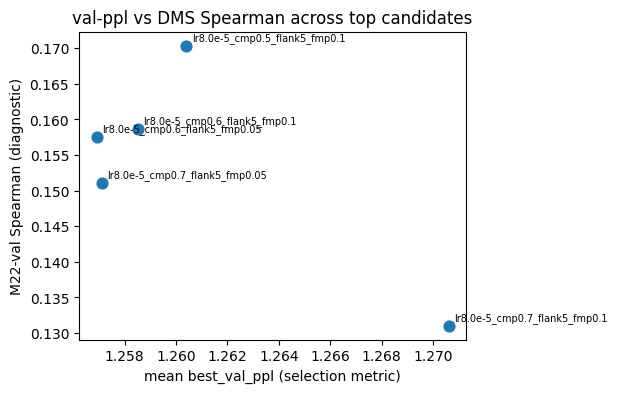

In [9]:
# === final comparison across salts (val ppl ± split std) ============
CONFIRM_SALTS = ["oas-v1", "oas-v2", "oas-v3"]

if not TOP_COMBOS:
    print("No TOP_COMBOS — run earlier cells first.")
else:
    recs = []
    for lr, cmp, flank, fmp in TOP_COMBOS:
        cdf = scan_grid([lr], [cmp], [flank], [fmp], CONFIRM_SALTS)
        ppls = {r.salt: r.best_val_ppl for _, r in cdf.iterrows() if r.finished}
        sps  = {r.salt: r.spearman_val for _, r in cdf.iterrows()
                if r.finished and not np.isnan(r.spearman_val)}
        vals = np.array([v for v in ppls.values() if not np.isnan(v)], dtype=float)
        sp_vals = np.array(list(sps.values()), dtype=float)
        recs.append(dict(
            combo=f"lr{lr}_cmp{cmp}_flank{flank}_fmp{fmp}",
            lr=lr, cmp=cmp, flank=flank, fmp=fmp,
            n_salts_done=len(vals),
            salts_done=",".join(sorted(ppls)),
            ppl_mean=float(vals.mean()) if len(vals) else np.nan,
            ppl_std=float(vals.std(ddof=0)) if len(vals) else np.nan,
            ppl_best=float(vals.min()) if len(vals) else np.nan,
            spearman_mean=float(sp_vals.mean()) if len(sp_vals) else np.nan,
        ))
    res = pd.DataFrame(recs).sort_values("ppl_mean")
    display(res.round(5).reset_index(drop=True))

    missing_conf = res[res["n_salts_done"] < len(CONFIRM_SALTS)]
    if not missing_conf.empty:
        print("NOTE: these candidates are missing some confirmation salts "
              "(partial — numbers provisional):")
        for _, r in missing_conf.iterrows():
            have = set(r.salts_done.split(",")) if r.salts_done else set()
            print(f"  {r.combo}: have [{r.salts_done}], "
                  f"missing [{','.join(sorted(set(CONFIRM_SALTS) - have))}]")

    ranked = res[res["ppl_mean"].notna()]
    if not ranked.empty:
        win = ranked.iloc[0]
        print(f"\nFINAL WINNER (rule = lowest MEAN val ppl across salts):")
        print(f"  {win.combo}  ppl_mean={win.ppl_mean:.5f} ± {win.ppl_std:.5f} "
              f"(n_salts={int(win.n_salts_done)})  ppl_best={win.ppl_best:.5f}")
        print(f"  -> register the best.pt of its lowest-ppl salt run in "
              f"conf/analysis/models.yaml (e.g. key 'vanilla_cdrmix_35m').")

        # diagnostic: val ppl vs logged Spearman per candidate
        diag = ranked[ranked["spearman_mean"].notna()]
        if not diag.empty:
            fig, ax = plt.subplots(figsize=(5, 4))
            ax.scatter(diag["ppl_mean"], diag["spearman_mean"], s=60)
            for _, r in diag.iterrows():
                ax.annotate(r.combo, (r.ppl_mean, r.spearman_mean),
                            fontsize=7, xytext=(4, 4), textcoords="offset points")
            ax.set_xlabel("mean best_val_ppl (selection metric)")
            ax.set_ylabel("M22-val Spearman (diagnostic)")
            ax.set_title("val-ppl vs DMS Spearman across top candidates")
            plt.show()
        else:
            print("\n(No scoring=c05 Spearman logged yet — run confirmation stage "
                  "to populate the ppl↔Spearman diagnostic.)")
